In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
ROOT = "/content/drive/MyDrive/3d_recon_points"
os.makedirs(ROOT, exist_ok=True)
os.chdir(ROOT)
print("ROOT:", os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT: /content/drive/MyDrive/3d_recon_points


In [ ]:
!pip -q install torch torchvision
!pip -q install open3d
!pip -q install gdown


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.0 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/xingyuansun/pix3d.git


Cloning into 'pix3d'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 36 (delta 0), reused 1 (delta 0), pack-reused 33 (from 1)
Receiving objects: 100% (36/36), 46.46 KiB | 914.00 KiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
!chmod +x pix3d/download_dataset.sh

In [ ]:
!cd pix3d && ./download_dataset.sh


Streaming output truncated to the last 5000 lines.
  inflating: mask/sofa/1654.png      
  inflating: mask/sofa/1592.png      
  inflating: mask/sofa/1235.png      
  inflating: mask/sofa/0807.png      
  inflating: mask/sofa/0475.png      
  inflating: mask/sofa/0303.png      
  inflating: mask/sofa/1931.png      
  inflating: mask/sofa/1543.png      
  inflating: mask/sofa/1122.png      
  inflating: mask/sofa/1685.png      
  inflating: mask/sofa/0762.png      
  inflating: mask/sofa/0989.png      
  inflating: mask/sofa/0958.png      
  inflating: mask/sofa/1653.png      
  inflating: mask/sofa/0013.png      
  inflating: mask/sofa/0472.png      
  inflating: mask/sofa/0800.png      
  inflating: mask/sofa/1232.png      
 extracting: mask/sofa/1595.png      
 extracting: mask/sofa/1544.png      
 extracting: mask/sofa/1936.png      
  inflating: mask/sofa/0304.png      
  inflating: mask/sofa/0765.png      
  inflating: mask/sofa/1682.png      
  inflating: mask/sofa/1125.png      

In [ ]:
!ls pix3d

demo.py			     download_dataset.sh  img	model	    README.md
download_baseline_output.sh  eval		  mask	pix3d.json


In [ ]:
!ls pix3d/img | head
!ls pix3d/model | head

bed
bookcase
chair
desk
misc
sofa
table
tool
wardrobe
bed
bookcase
chair
desk
misc
sofa
table
tool
wardrobe


In [ ]:
!pip -q install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.0/737.0 kB 17.9 MB/s eta 0:00:00


In [ ]:
import os
os.makedirs("pix3d/points", exist_ok=True)

In [ ]:
import os
import json
import trimesh
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
with open("pix3d/pix3d.json", "r") as f:
    anns = json.load(f)

print(anns[0].keys())
print(anns[0]["category"])
print(anns[0]["img"])
print(anns[0]["model"])


dict_keys(['img', 'category', 'img_size', '2d_keypoints', 'mask', 'img_source', 'model', 'model_raw', 'model_source', '3d_keypoints', 'voxel', 'rot_mat', 'trans_mat', 'focal_length', 'cam_position', 'inplane_rotation', 'truncated', 'occluded', 'slightly_occluded', 'bbox'])
bed
img/bed/0001.png
model/bed/IKEA_MALM_2/model.obj


In [ ]:
# ANN_PATH = "pix3d/pix3d.json"
# ROOT = "pix3d"
# OUT_PTS = "pix3d/points"
# OUT_MAP = "pix3d/point_map.json"

# os.makedirs(OUT_PTS, exist_ok=True)

# NUM_POINTS = 1024
# MAX_SAMPLES = 200

# with open(ANN_PATH, "r") as f:
#     anns = json.load(f)

# mapping = []
# count = 0

# for ann in tqdm(anns):
#     if "chair" not in ann["category"].lower():
#         continue

#     img_path = os.path.join(ROOT, ann["img"])
#     model_path = os.path.join(ROOT, ann["model"])

#     if not (os.path.exists(img_path) and os.path.exists(model_path)):
#         continue

#     try:
#         mesh = trimesh.load(model_path, force="mesh")
#         points, _ = trimesh.sample.sample_surface(mesh, NUM_POINTS)

#         base = f"sample_{count:04d}"
#         np.save(os.path.join(OUT_PTS, base + ".npy"), points)

#         mapping.append({
#             "points": base + ".npy",
#             "image": ann["img"]   # KEEP RELATIVE PATH
#         })

#         count += 1
#         if count >= MAX_SAMPLES:
#             break
#     except Exception as e:
#         continue

# with open(OUT_MAP, "w") as f:
#     json.dump(mapping, f, indent=2)

# print("Saved samples:", count)
# print("Mapping file written to:", OUT_MAP)


In [ ]:
!ls pix3d/points | wc -l


200


In [ ]:
!ls pix3d | grep point_map


point_map.json


In [ ]:
class Pix3DPointDataset(Dataset):
    def __init__(self, root="pix3d"):
        self.root = root

        with open(os.path.join(root, "point_map.json"), "r") as f:
            self.items = json.load(f)

        self.tf = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]

        img_path = os.path.join(self.root, item["image"])
        pts_path = os.path.join(self.root, "points", item["points"])

        img = Image.open(img_path).convert("RGB")
        img = self.tf(img)

        pts = torch.from_numpy(np.load(pts_path)).float()

        return img, pts


In [ ]:
!ls pix3d



demo.py			     download_dataset.sh  img	model	    points
download_baseline_output.sh  eval		  mask	pix3d.json  README.md


In [ ]:
from torch.utils.data import DataLoader

dataset = Pix3DPointDataset("pix3d")
loader = DataLoader(dataset, batch_size=8, shuffle=True, drop_last=True)

imgs, pts = next(iter(loader))
print(imgs.shape)   # [8, 3, 224, 224]
print(pts.shape)    # [8, 1024, 3]


torch.Size([8, 3, 224, 224])
torch.Size([8, 1024, 3])


model, optimizer

In [ ]:
class PointNetRecon(nn.Module):
    def __init__(self, num_points=1024):
        super().__init__()
        # Encoder
        self.encoder = models.resnet18(pretrained=True)
        self.encoder.fc = nn.Identity()   # output: 512

        # Freeze encoder for stability
        for p in self.encoder.parameters():
            p.requires_grad = False

        # Point prediction head
        self.head = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, num_points * 3)
        )

        self.num_points = num_points

    def forward(self, x):
        z = self.encoder(x)
        pts = self.head(z)
        return pts.view(-1, self.num_points, 3)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PointNetRecon(num_points=1024).to(device)
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)

print("Using device:", device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Using device: cuda


In [ ]:
CKPT_PATH = "checkpoints/pointnet_pix3d.pt"
os.makedirs("checkpoints", exist_ok=True)

In [ ]:
def chamfer_distance(p1, p2):
    """
    p1: (B, N, 3)
    p2: (B, M, 3)
    """
    # pairwise squared distances
    diff = p1.unsqueeze(2) - p2.unsqueeze(1)   # (B, N, M, 3)
    dist = torch.sum(diff ** 2, dim=-1)        # (B, N, M)

    min_p1, _ = torch.min(dist, dim=2)          # (B, N)
    min_p2, _ = torch.min(dist, dim=1)          # (B, M)

    return min_p1.mean() + min_p2.mean()


training

In [ ]:
from torch.utils.data import random_split

val_ratio = 0.2
n_total = len(dataset)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

train_set, val_set = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_set, batch_size=8, shuffle=False)


In [ ]:
def evaluate(model, loader):
    model.eval()
    total = 0.0
    total_f1 = 0.0
    with torch.no_grad():
        for imgs, gt_pts in loader:
            imgs = imgs.to(device)
            gt_pts = gt_pts.to(device)

            pred = model(imgs)
            loss = chamfer_distance(pred, gt_pts)

            total += loss.item()
            total_f1 += fscore_at_threshold(pred, gt_pts, tau=0.05)

    return total / len(loader), total_f1 / len(loader)


In [ ]:
EPOCHS = 10
start_epoch = 0
train_losses = []
val_losses = []

for ep in range(start_epoch, start_epoch + EPOCHS):
    model.train()
    total = 0.0

    for imgs, gt_pts in train_loader:
        imgs = imgs.to(device)
        gt_pts = gt_pts.to(device)

        pred = model(imgs)
        loss = chamfer_distance(pred, gt_pts)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    train_loss = total / len(train_loader)
    val_loss = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {ep+1}: train={train_loss:.4f}, val={val_loss:.4f}")

    # SAVE FULL CHECKPOINT EVERY EPOCH
    torch.save({
        "epoch": ep + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "num_points": model.num_points,
        "lr": optimizer.param_groups[0]["lr"]
    }, CKPT_PATH)


Epoch 1: train=0.0017, val=0.0016
Epoch 2: train=0.0019, val=0.0023
Epoch 3: train=0.0017, val=0.0019
Epoch 4: train=0.0016, val=0.0025
Epoch 5: train=0.0018, val=0.0025
Epoch 6: train=0.0017, val=0.0021
Epoch 7: train=0.0015, val=0.0018
Epoch 8: train=0.0015, val=0.0016
Epoch 9: train=0.0014, val=0.0017
Epoch 10: train=0.0015, val=0.0018


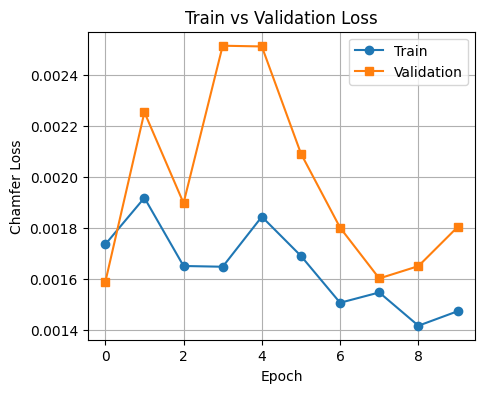

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.plot(train_losses, label="Train", marker="o")
plt.plot(val_losses, label="Validation", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Chamfer Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


### resume training

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PointNetRecon(num_points=1024).to(device)
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
CKPT_PATH = "checkpoints/pointnet_pix3d.pt"

model = PointNetRecon(num_points=1024).to(device)
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)

ckpt = torch.load(CKPT_PATH, map_location=device)

model.load_state_dict(ckpt["model_state"])
optimizer.load_state_dict(ckpt["optimizer_state"])

start_epoch = ckpt["epoch"]
train_losses = ckpt["train_losses"]
val_losses = ckpt["val_losses"]

print("Resumed from epoch:", start_epoch)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Resumed from epoch: 10


In [ ]:
EXTRA_EPOCHS = 10

for ep in range(start_epoch, start_epoch + EXTRA_EPOCHS):
    model.train()
    total = 0.0

    for imgs, gt_pts in train_loader:
        imgs = imgs.to(device)
        gt_pts = gt_pts.to(device)

        pred = model(imgs)
        loss = chamfer_distance(pred, gt_pts)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    train_loss = total / len(train_loader)
    val_loss = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {ep+1}: train={train_loss:.4f}, val={val_loss:.4f}")

    torch.save({
        "epoch": ep + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "num_points": model.num_points,
        "lr": optimizer.param_groups[0]["lr"]
    }, CKPT_PATH)


Epoch 11: train=0.0015, val=0.0016
Epoch 12: train=0.0015, val=0.0014
Epoch 13: train=0.0015, val=0.0016
Epoch 14: train=0.0015, val=0.0015
Epoch 15: train=0.0014, val=0.0015
Epoch 16: train=0.0015, val=0.0016
Epoch 17: train=0.0013, val=0.0017
Epoch 18: train=0.0013, val=0.0014
Epoch 19: train=0.0013, val=0.0016
Epoch 20: train=0.0016, val=0.0015


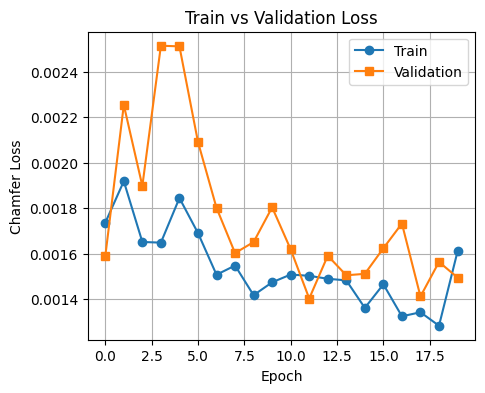

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.plot(train_losses, label="Train", marker="o")
plt.plot(val_losses, label="Validation", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Chamfer Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


resume 2

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PointNetRecon(num_points=1024).to(device)
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 99.9MB/s]


In [ ]:
CKPT_PATH = "checkpoints/pointnet_pix3d.pt"

model = PointNetRecon(num_points=1024).to(device)
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)

ckpt = torch.load(CKPT_PATH, map_location=device)

model.load_state_dict(ckpt["model_state"])
optimizer.load_state_dict(ckpt["optimizer_state"])

start_epoch = ckpt["epoch"]
train_losses = ckpt["train_losses"]
val_losses = ckpt["val_losses"]

print("Resumed from epoch:", start_epoch)


Resumed from epoch: 20


In [ ]:
EXTRA_EPOCHS = 10

for ep in range(start_epoch, start_epoch + EXTRA_EPOCHS):
    model.train()
    total = 0.0

    for imgs, gt_pts in train_loader:
        imgs = imgs.to(device)
        gt_pts = gt_pts.to(device)

        pred = model(imgs)
        loss = chamfer_distance(pred, gt_pts)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    train_loss = total / len(train_loader)
    val_loss = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {ep+1}: train={train_loss:.4f}, val={val_loss:.4f}")

    torch.save({
        "epoch": ep + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "num_points": model.num_points,
        "lr": optimizer.param_groups[0]["lr"]
    }, CKPT_PATH)


Epoch 21: train=0.0015, val=0.0017
Epoch 22: train=0.0014, val=0.0017
Epoch 23: train=0.0013, val=0.0014
Epoch 24: train=0.0017, val=0.0018
Epoch 25: train=0.0021, val=0.0019
Epoch 26: train=0.0017, val=0.0017
Epoch 27: train=0.0014, val=0.0015
Epoch 28: train=0.0014, val=0.0014
Epoch 29: train=0.0013, val=0.0017
Epoch 30: train=0.0013, val=0.0016


resume 3

In [ ]:
CKPT_PATH = "checkpoints/pointnet_pix3d.pt"

model = PointNetRecon(num_points=1024).to(device)
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)

ckpt = torch.load(CKPT_PATH, map_location=device)

model.load_state_dict(ckpt["model_state"])
optimizer.load_state_dict(ckpt["optimizer_state"])

start_epoch = ckpt["epoch"]
train_losses = ckpt["train_losses"]
val_losses = ckpt["val_losses"]

print("Resumed from epoch:", start_epoch)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Resumed from epoch: 30


In [ ]:
EXTRA_EPOCHS = 10

for ep in range(start_epoch, start_epoch + EXTRA_EPOCHS):
    model.train()
    total = 0.0

    for imgs, gt_pts in train_loader:
        imgs = imgs.to(device)
        gt_pts = gt_pts.to(device)

        pred = model(imgs)
        loss = chamfer_distance(pred, gt_pts)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    train_loss = total / len(train_loader)
    val_loss = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {ep+1}: train={train_loss:.4f}, val={val_loss:.4f}")

    torch.save({
        "epoch": ep + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "num_points": model.num_points,
        "lr": optimizer.param_groups[0]["lr"]
    }, CKPT_PATH)


Epoch 31: train=0.0014, val=0.0014
Epoch 32: train=0.0012, val=0.0014
Epoch 33: train=0.0012, val=0.0014
Epoch 34: train=0.0013, val=0.0015
Epoch 35: train=0.0012, val=0.0013
Epoch 36: train=0.0012, val=0.0016
Epoch 37: train=0.0012, val=0.0016
Epoch 38: train=0.0011, val=0.0014
Epoch 39: train=0.0012, val=0.0014
Epoch 40: train=0.0013, val=0.0014


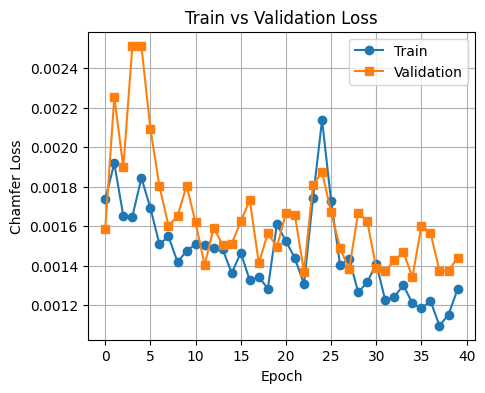

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.plot(train_losses, label="Train", marker="o")
plt.plot(val_losses, label="Validation", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Chamfer Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def calculate_f1_score(tp, fp, fn):
    """
    Calculates the F1-score.

    Args:
        tp (int): True Positives
        fp (int): False Positives
        fn (int): False Negatives

    Returns:
        float: The F1-score, or 0.0 if precision and recall are both zero.
    """
    if tp + fp == 0:
        precision = 0.0
    else:
        precision = tp / (tp + fp)

    if tp + fn == 0:
        recall = 0.0
    else:
        recall = tp / (tp + fn)

    if precision + recall == 0:
        f1_score = 0.0
    else:
        f1_score = 2 * (precision * recall) / (precision + recall)

    return f1_score

F1-Score: 0.8421


In [ ]:
model = PointNetRecon(num_points=1024).to(device)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()


PointNetRecon(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [ ]:
def fscore_at_threshold(pred, gt, tau=0.05):
    # pred, gt: (B, N, 3)
    dist = torch.cdist(pred, gt)  # (B, N, N)

    # precision: predicted points close to some gt
    min_pred_to_gt = dist.min(dim=2)[0]  # (B, N)
    precision = (min_pred_to_gt < tau).float().mean(dim=1)  # (B,)

    # recall: gt points covered by prediction
    min_gt_to_pred = dist.min(dim=1)[0]  # (B, N)
    recall = (min_gt_to_pred < tau).float().mean(dim=1)  # (B,)

    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return f1.mean().item()


In [ ]:
val_f1 = 0.0
n = 0

with torch.no_grad():
    for imgs, gt_pts in val_loader:
        imgs = imgs.to(device)
        gt_pts = gt_pts.to(device)

        pred = model(imgs)
        val_f1 += fscore_at_threshold(pred, gt_pts, tau=0.035)
        n += 1

val_f1 /= n
print("Validation F1:", val_f1)


Validation F1: 0.9298385858535767


In [ ]:
import open3d as o3d

In [ ]:
os.makedirs("outputs/pcd", exist_ok=True)
os.makedirs("outputs/png", exist_ok=True)
os.makedirs("outputs/meta", exist_ok=True)
N_SAVE = 15

def save_pcd(points, path, color):
    if hasattr(points, "detach"):
        points = points.detach().cpu().numpy()
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    pcd.paint_uniform_color(color)
    o3d.io.write_point_cloud(path, pcd)

model.eval()
saved = 0

with torch.no_grad():
    for i, (imgs, gt_pts) in enumerate(val_loader):
        imgs = imgs.to(device)
        preds = model(imgs)

        for b in range(imgs.size(0)):
            if saved >= N_SAVE:
                break

            idx = f"sample_{saved:02d}"
            save_pcd(gt_pts[b],   f"outputs/pcd/{idx}_gt.ply",   [0,1,0])
            save_pcd(preds[b],    f"outputs/pcd/{idx}_pred.ply", [1,0,0])

            # metadata
            meta = {
                "index": idx,
                "epoch": start_epoch if 'start_epoch' in globals() else None
            }
            with open(f"outputs/meta/{idx}.json", "w") as f:
                json.dump(meta, f, indent=2)

            saved += 1
        if saved >= N_SAVE:
            break

print("Saved samples:", saved)


Saved samples: 15


## Load Trained Model

Load the trained `PointNetRecon` model from the latest checkpoint file (`checkpoints/pointnet_pix3d.pt`) to ensure we use the model with the best performance for inference.


In [ ]:
import os
import torch
import numpy as np
from PIL import Image
import open3d as o3d
import datetime # Import datetime for unique filenames

# Create the output directory for dataset samples
default_output_dir = "outputs_demo"
os.makedirs(default_output_dir, exist_ok=True)

# --- USER INPUT SECTION ---
# To use your own image:
# 1. Upload your image file to your Colab environment (e.g., drag and drop into the files pane).
# 2. Update the 'manual_image_path' variable below with the path to your uploaded image.
#    Example: manual_image_path = "/content/my_uploaded_image.png"
# 3. If a manual image is provided, ground truth comparison will not be available for it.
manual_image_path = "/content/chair.png"
# --------------------------

# Put model in evaluation mode
model.eval()

original_gt_points = None # Initialize ground truth points to None

if manual_image_path:
    print(f"Using manual input image: {manual_image_path}")
    if not os.path.exists(manual_image_path):
        raise FileNotFoundError(f"User image not found at {manual_image_path}. Please upload your image and update the path.")

    # Load the manual image and apply dataset transforms
    # Assumes 'dataset' object from previous steps is available and has a 'tf' attribute
    user_img_pil = Image.open(manual_image_path).convert("RGB")
    input_image_tensor = dataset.tf(user_img_pil).cpu() # Preprocessed tensor for saving
    input_image_gpu = input_image_tensor.unsqueeze(0).to(device) # Add batch dimension for model input
    current_output_dir = "outputs_user_input" # Separate folder for user inputs
    os.makedirs(current_output_dir, exist_ok=True)

else:
    print("Using a random sample from the validation dataset.")
    # Get one sample from the validation loader
    with torch.no_grad():
        sample_imgs, sample_gt_pts = next(iter(val_loader))

    # Take the first item from the batch
    input_image_tensor = sample_imgs[0].cpu() # For saving
    original_gt_points = sample_gt_pts[0].cpu() # Ground truth points
    input_image_gpu = sample_imgs[0].unsqueeze(0).to(device) # Add batch dimension
    current_output_dir = default_output_dir # Use the default for dataset samples

# Generate a timestamp for unique filenames
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Perform inference with the model
with torch.no_grad():
    predicted_points = model(input_image_gpu).squeeze(0).cpu() # Remove batch dim and move to CPU

# Define helper to save point clouds
def save_pcd(points, path, color=None):
    if isinstance(points, torch.Tensor):
        points = points.detach().numpy()
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    if color:
        pcd.paint_uniform_color(color)
    o3d.io.write_point_cloud(path, pcd)

# 1. Save the input 2D image
# Convert tensor to PIL Image (undo normalization if applied - assuming [0,1] range for ToTensor() output)
img_np = (input_image_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8) # Convert CHW to HWC, scale to 0-255
img_pil_saved = Image.fromarray(img_np)
img_path = os.path.join(current_output_dir, f"input_image_{timestamp}.png")
img_pil_saved.save(img_path)
print(f"Saved input 2D image to: {img_path}")

# 2. Save the ground truth 3D point cloud (if available)
if original_gt_points is not None:
    gt_pcd_path = os.path.join(current_output_dir, f"ground_truth_pcd_{timestamp}.ply")
    save_pcd(original_gt_points, gt_pcd_path, color=[0, 1, 0]) # Green for ground truth
    print(f"Saved ground truth point cloud to: {gt_pcd_path}")
else:
    print("No ground truth point cloud available for this input.")

# 3. Save the predicted 3D point cloud
pred_pcd_path = os.path.join(current_output_dir, f"predicted_pcd_{timestamp}.ply")
save_pcd(predicted_points, pred_pcd_path, color=[1, 0, 0]) # Red for predicted
print(f"Saved predicted point cloud to: {pred_pcd_path}")

print(f"\nAll output files can be found in the directory: {os.path.abspath(current_output_dir)}")

Using manual input image: /content/chair.png
Saved input 2D image to: outputs_user_input/input_image_20251222_153847.png
No ground truth point cloud available for this input.
Saved predicted point cloud to: outputs_user_input/predicted_pcd_20251222_153847.ply

All output files can be found in the directory: /content/drive/MyDrive/3d_recon_points/outputs_user_input
